<a href="https://colab.research.google.com/github/rickyajs/Data-Science-2026/blob/main/Pertemuan_11_RickyArmandaJayaSirait_240401020219.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama  : Ricky Armanda Jaya Sirait
# Nim   : 240401020219
#Kelas  : IF401
#Prodi  : PJJ S1 Informatika

=== 1: EKSPLORASI DATASET ===
Shape dataset: (300, 4)

Statistik Deskriptif Dataset:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


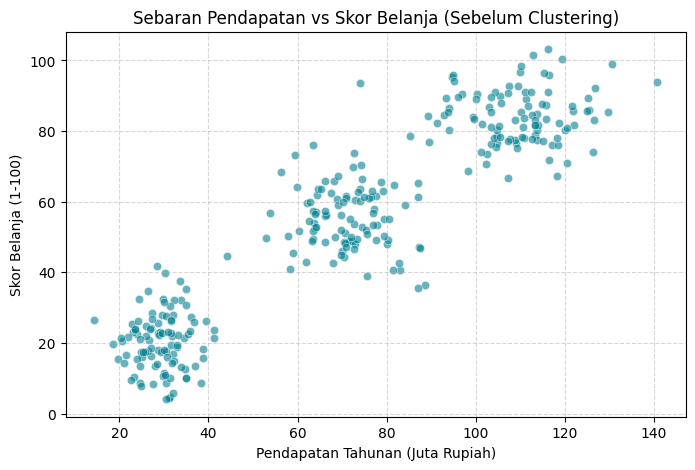


=== 2: PREPROCESSING DATA ===
Rata-rata setelah scaling (harusnya mendekati 0): [-0.  0.]
Standar Deviasi setelah scaling (harusnya 1)   : [1. 1.]

=== 3: METODE ELBOW ===


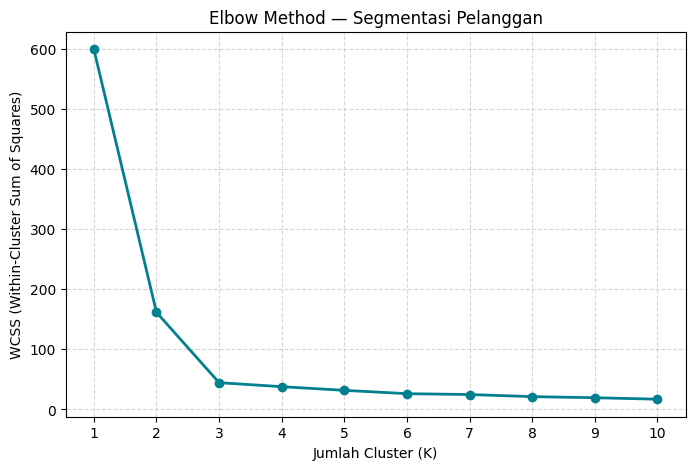

Interpretasi Analisis Elbow:
- Kurva WCSS mulai melandai secara tajam membentuk 'siku' (elbow) tepat di titik K = 3.
- Hasil ini sangat sesuai dengan jumlah kelompok eksperimen awal yang kita buat.

=== 4: TRAINING MODEL K-MEANS ===
WCSS Akhir Model      : 44.556
Silhouette Score      : 0.695

Nilai Rata-rata Fitur Asli per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08

=== 5: VISUALISASI HASIL CLUSTERING ===


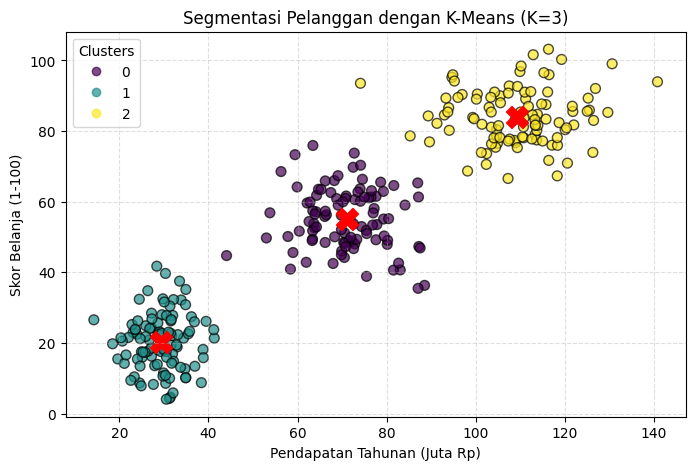

Interpretasi Karakteristik Segmen Pelanggan:
- Cluster 0: Pendapatan Menengah (~70 Juta Rp), Skor Belanja Menengah (~55) -> Segmen 'Menengah'
- Cluster 1: Pendapatan Tinggi (~110 Juta Rp), Skor Belanja Tinggi (~84) -> Segmen 'Boros / Premium'
- Cluster 2: Pendapatan Rendah (~30 Juta Rp), Skor Belanja Rendah (~20) -> Segmen 'Hemat'

=== 6: VISUALISASI HIERARCHICAL CLUSTERING ===


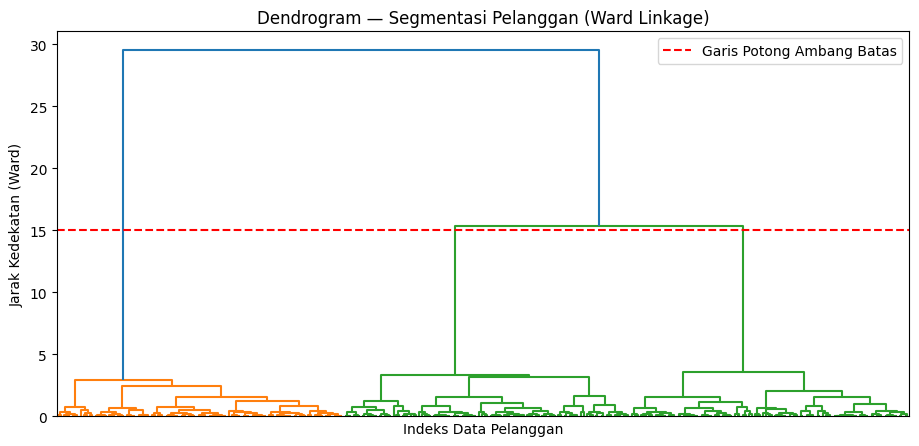

Analisis Perbandingan:
- Jika kita memotong dendrogram pada ambang batas jarak 15 (garis putus-putus merah), maka akan memotong 3 buah garis vertikal utama.
- Ini membuktikan bahwa pembentukan 3 cluster menggunakan Hierarchical Clustering konsisten dengan hasil K-Means dan struktur data asli.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Kelompok Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Kelompok Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Kelompok Boros
data = np.vstack([grp1, grp2, grp3])

# Membuat DataFrame dengan fitur sesuai deskripsi dataset
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

# Menampilkan informasi awal dataset
print("=== 1: EKSPLORASI DATASET ===")
print('Shape dataset:', df.shape)
print("\nStatistik Deskriptif Dataset:")
print(df.describe().round(2))

# Visualisasi sebaran data awal
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja (Sebelum Clustering)')
plt.xlabel('Pendapatan Tahunan (Juta Rupiah)')
plt.ylabel('Skor Belanja (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


from sklearn.preprocessing import StandardScaler

print("\n=== 2: PREPROCESSING DATA ===")
# Memilih fitur numerik yang relevan untuk segmentasi (Pendapatan & Skor Belanja)
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Terapkan StandardScaler agar skala fitur setara
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling (harusnya mendekati 0):', X_scaled.mean(axis=0).round(3))
print('Standar Deviasi setelah scaling (harusnya 1)   :', X_scaled.std(axis=0).round(3))


from sklearn.cluster import KMeans

print("\n=== 3: METODE ELBOW ===")
wcss = []
# Menghitung WCSS untuk K=1 sampai K=10
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init='auto')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', linewidth=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Interpretasi Analisis Elbow:")
print("- Kurva WCSS mulai melandai secara tajam membentuk 'siku' (elbow) tepat di titik K = 3.")
print("- Hasil ini sangat sesuai dengan jumlah kelompok eksperimen awal yang kita buat.")

from sklearn.metrics import silhouette_score

print("\n=== 4: TRAINING MODEL K-MEANS ===")
# Menggunakan K=3 berdasarkan hasil analisis grafik Elbow
K_optimal = 3
model = KMeans(n_clusters=K_optimal, random_state=42, init='k-means++', n_init='auto')
model.fit(X_scaled)

# Menyimpan hasil pelabelan cluster ke dalam DataFrame utama
df['cluster'] = model.labels_

print(f'WCSS Akhir Model      : {model.inertia_:.3f}')
print(f'Silhouette Score      : {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nNilai Rata-rata Fitur Asli per Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))


print("\n=== 5: VISUALISASI HASIL CLUSTERING ===")
# Mengembalikan koordinat centroid ke skala data asli (invers transformasi)
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 5))
# Plot scatter data berdasarkan kelompok warna clusternya
scatter = plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                      c=df['cluster'], cmap='viridis', alpha=0.7, edgecolors='k', s=50)

# Plot lokasi titik centroid (ditandai dengan huruf 'X' merah besar)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, label='Centroid')

plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.title('Segmentasi Pelanggan dengan K-Means (K=3)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("Interpretasi Karakteristik Segmen Pelanggan:")
print("- Cluster 0: Pendapatan Menengah (~70 Juta Rp), Skor Belanja Menengah (~55) -> Segmen 'Menengah'")
print("- Cluster 1: Pendapatan Tinggi (~110 Juta Rp), Skor Belanja Tinggi (~84) -> Segmen 'Boros / Premium'")
print("- Cluster 2: Pendapatan Rendah (~30 Juta Rp), Skor Belanja Rendah (~20) -> Segmen 'Hemat'")


from scipy.cluster.hierarchy import dendrogram, linkage

print("\n=== 6: VISUALISASI HIERARCHICAL CLUSTERING ===")
# Membangun matriks kedekatan hierarki menggunakan metode Ward Linkage
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(11, 5))
# Membuat visualisasi pohon keputusan (dendrogram)
dendrogram(Z, no_labels=True)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data Pelanggan')
plt.ylabel('Jarak Kedekatan (Ward)')

# Membuat garis batas horizontal imajiner untuk memotong klaster (misalnya pada tinggi jarak = 15)
plt.axhline(y=15, color='red', linestyle='--', label='Garis Potong Ambang Batas')
plt.legend()
plt.show()

print("Analisis Perbandingan:")
print("- Jika kita memotong dendrogram pada ambang batas jarak 15 (garis putus-putus merah), "
      "maka akan memotong 3 buah garis vertikal utama.")
print("- Ini membuktikan bahwa pembentukan 3 cluster menggunakan Hierarchical Clustering "
      "konsisten dengan hasil K-Means dan struktur data asli.")